In [1]:
import pandas, urllib, numpy

In [2]:
import statsmodels, statsmodels.stats, statsmodels.stats.multitest

In [3]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [4]:
# pip install git+https://github.com/Maayanlab/maayanlab-bioinformatics.git
import maayanlab_bioinformatics, maayanlab_bioinformatics.enrichment

# define library

In [5]:
enrichr_library = 'Reactome_Pathways_2024'

# read data

In [6]:
df = pandas.read_csv('029 orsay Table DEGs - both HOM & VGA.tsv', sep='\t')
original = df['Gene name'].values
gene_list_input = [element.upper() for element in original]
print(len(gene_list_input), gene_list_input[:10])
# it should be 85 as one is lost bc it was a nan gene, ha!

85 ['C3', 'KRT80', 'SHTN1', 'LY6C2', 'PPP1R13L', 'SORL1', 'KRT6A', 'LAD1', 'EMB', 'LY6D']


In [7]:
def get_library(lib_name):
    '''
    Returns a dictionary mapping each term from the input library to 
    its associated geneset. 
    '''
    raw_lib_data = []

    with urllib.request.urlopen('https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName=' + lib_name) as f:
        for line in f.readlines():
            raw_lib_data.append(line.decode("utf-8").split("\t\t"))

    name = []
    gene_list = []
    lib_data = {}

    for i in range(len(raw_lib_data)):
        name += [raw_lib_data[i][0]]
        raw_genes = raw_lib_data[i][1].replace('\t', ' ')
        gene_list += [raw_genes[:-1]]
    
    lib_data = {a[0]:a[1].split(' ') for a in zip(name, gene_list)}
    return lib_data

lib_data = get_library(enrichr_library)

enrich_results = maayanlab_bioinformatics.enrichment.enrich_crisp(gene_list_input, lib_data, 21000, True)

res_df = pandas.DataFrame(
    [ [
        term, 
        res.pvalue, 
        res.odds_ratio,
        res.n_overlap,

    ] for (term, res) in enrich_results ], 
    columns=['term', 'pvalue', 'odds_ratio', 'n_overlap']
)
res_df

,term,pvalue,odds_ratio,n_overlap
0,AMPK Inhibits chREBP Transcriptional Activatio...,0.035851,31.111607,1
1,Activation of BAD and Translocation to Mitocho...,0.062854,16.587302,1
2,Activation of BH3-only Proteins,0.118227,8.287698,1
3,Activation of C3 and C5,0.031931,35.557823,1
4,"Activation of IRF3, IRF7 Mediated by TBK1, IKK...",0.074197,13.820767,1
...,...,...,...,...
274,VLDL Clearance,0.000336,100.771084,2
275,Vasopressin Regulates Renal Water Homeostasis ...,0.163593,5.778516,1
276,Vesicle-mediated Transport,0.363667,1.329575,4
277,Viral Infection Pathways,0.928491,0.460496,2


In [8]:
# add gene names
container = []
for pathway in res_df['term']:
    
    overlap_genes = []
    for query in lib_data[pathway]:
        if query in gene_list_input:
            overlap_genes.append(query)
    mouse_overlap_genes = [element.lower().title() for element in overlap_genes]
    overlap_genes_string = ', '.join(mouse_overlap_genes)
    container.append(overlap_genes_string)

res_df.loc[:, 'overlap_genes'] = container
res_df

,term,pvalue,odds_ratio,n_overlap,overlap_genes
0,AMPK Inhibits chREBP Transcriptional Activatio...,0.035851,31.111607,1,Adipoq
1,Activation of BAD and Translocation to Mitocho...,0.062854,16.587302,1,Sfn
2,Activation of BH3-only Proteins,0.118227,8.287698,1,Sfn
3,Activation of C3 and C5,0.031931,35.557823,1,C3
4,"Activation of IRF3, IRF7 Mediated by TBK1, IKK...",0.074197,13.820767,1,Irf7
...,...,...,...,...,...
274,VLDL Clearance,0.000336,100.771084,2,"Apoc1, Lsr"
275,Vasopressin Regulates Renal Water Homeostasis ...,0.163593,5.778516,1,Aqp3
276,Vesicle-mediated Transport,0.363667,1.329575,4,"Sfn, Hp, Klc3, Col7A1"
277,Viral Infection Pathways,0.928491,0.460496,2,"Sfn, Irf7"


In [9]:
# multiple test correction
results = statsmodels.stats.multitest.multipletests(res_df['pvalue'], alpha=0.05, method='fdr_bh')
res_df['adjusted'] = results[1]

(267, 6)
(12, 6)
1	1.1698678346499414	Formation of the Cornified Envelope	1.3440172132174824e-09
2	1.0266767818927396	Developmental Biology	0.0008330415655750451
3	1.0020397686796805	VLDL Clearance	0.015603649233078437
4	0.9198310528300819	Keratinization	1.7799981986091048e-07
5	0.8689879826522205	Apoptotic Cleavage of Cell Adhesion Proteins	0.00095650980172525
6	0.480614864097414	Type I Hemidesmosome Assembly	0.03226574264031053
7	0.376872720950817	Neutrophil Degranulation	0.024961139566375634
8	0.20725412639269747	Degradation of the Extracellular Matrix	0.015115860619736287
9	0.19562207805522272	Apoptotic Cleavage of Cellular Proteins	0.020982286325838442
10	0.13614593266351274	Cell Junction Organization	0.0364543671717911


/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_3215/2150456358.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b.loc[:, 'importance'] = importance


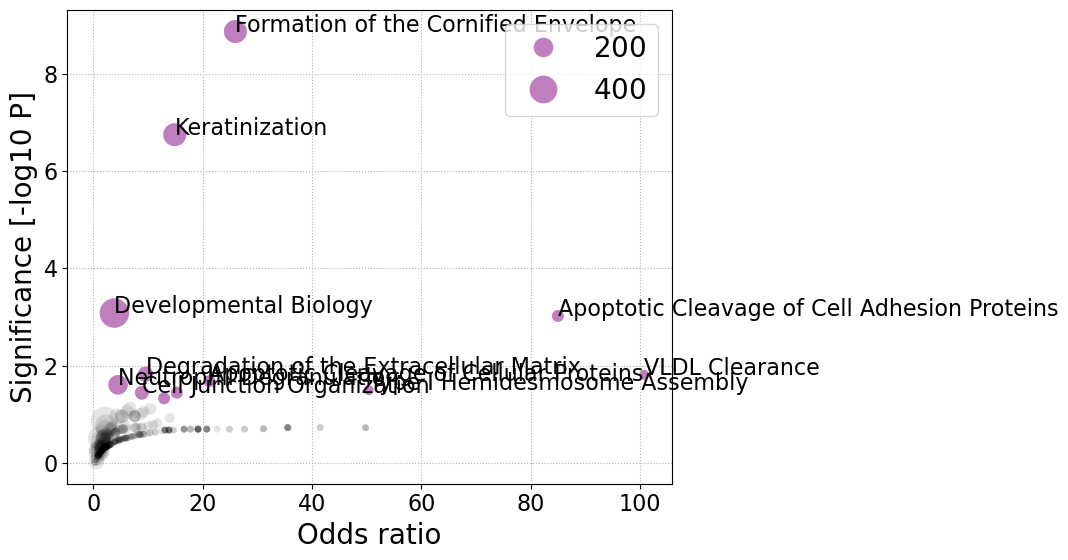

In [10]:
# plot

def importance_calculator(x, y, w):

    xnorm = (x - numpy.min(x)) / (numpy.max(x) - numpy.min(x))
    ynorm = (y - numpy.min(y)) / (numpy.max(y) - numpy.min(y))
    wnorm = (w - numpy.min(w)) / (numpy.max(w) - numpy.min(w))
    
    importance = [numpy.sqrt(xnorm[i]**2 + ynorm[i]**2 + wnorm[i]**2) for i in range(len(x))]
    return importance

inflation = 25

a = res_df[(res_df['adjusted'] > 0.05) | (res_df['odds_ratio'] < 2)]
print(a.shape)
x = a['odds_ratio']
y = -numpy.log10(a['adjusted'])
s = a['n_overlap']
matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/10, edgecolors='none', color='black')

b = res_df[(res_df['adjusted'] < 0.05) & (res_df['odds_ratio'] > 2)]
print(b.shape)
x = b['odds_ratio']
y = -numpy.log10(b['adjusted'])
s = b['n_overlap']
sc = matplotlib.pyplot.scatter(x, y, s*inflation, alpha=1/2, edgecolors='none', color='purple')

x = list(b['odds_ratio'])
y = list(-numpy.log10(b['adjusted']))
prez = list(b['term'].values)
z = [element.split()[-1] for element in prez]
importance = importance_calculator(x, y, s.values)
b.loc[:, 'importance'] = importance
c = b.sort_values('importance', ascending=False)

threshold = importance[numpy.argsort(importance)[::-1][10]] # gimme the top 10
com = c[c['importance'] > threshold]
count = 0
for index, row in com.iterrows():
    x = row['odds_ratio']
    y = -numpy.log10(row['adjusted'])
    
    label = ' '.join(row['term'].split()[:2])
    label = row['term']
    matplotlib.pyplot.text(x, y, label, fontsize=16)
    count = count + 1
    print('{}\t{}\t{}\t{}'.format(count, row['importance'], row['term'], row['adjusted']))

matplotlib.pyplot.legend(*sc.legend_elements("sizes", num=3, color='purple', alpha=1/2, mew=0), loc=1)
matplotlib.pyplot.xlabel('Odds ratio')
matplotlib.pyplot.ylabel('Significance [-log10 P]')
matplotlib.pyplot.grid(ls=':', alpha=1)
matplotlib.pyplot.tight_layout()

matplotlib.pyplot.show()
#matplotlib.pyplot.savefig('hom.svg')

In [11]:
# store list 
print(c.shape)
c.drop('pvalue', axis='columns', inplace=True)
d = c.iloc[:, [0, 5, 4, 1, 2, 3]]
d.rename(columns={"term": "Term", 
                  "importance": "Priority", 
                  'adjusted':'Adjusted P', 
                  'odds_ratio':'Odds ratio',
                 'n_overlap':'N overlap',
                 'overlap_genes':'Overlap genes'}, inplace=True)
d.set_index('Term', inplace=True)
d.head()
d.to_csv('particular2both.wikipathways.tsv', sep='\t')

d

(12, 7)


,Priority,Adjusted P,Odds ratio,N overlap,Overlap genes
Term,,,,,
Formation of the Cornified Envelope,1.169868,1.344017e-09,25.977288,11,"Krt5, Pkp3, Pkp1, Krt6A, Perp, Sprr1A, Krt14, ..."
Developmental Biology,1.026677,8.330416e-04,3.832770,18,"Pkp3, Pkp1, Dsp, Shtn1, Ptprc, Perp, Zic1, Cdh..."
VLDL Clearance,1.002040,1.560365e-02,100.771084,2,"Apoc1, Lsr"
Keratinization,0.919831,1.779998e-07,14.870610,11,"Krt5, Sprr1A, Krt14, Krt17, Krt16, Pkp3, Pkp1,..."
Apoptotic Cleavage of Cell Adhesion Proteins,0.868988,9.565098e-04,84.983740,3,"Dsp, Cdh1, Pkp1"
Type I Hemidesmosome Assembly,0.480615,3.226574e-02,50.373494,2,"Krt5, Krt14"
Neutrophil Degranulation,0.376873,2.496114e-02,4.509664,8,"C3, Pkp1, Hp, Dsp, Lgals3, Ptprc, Ctss, Cybb"
Degradation of the Extracellular Matrix,0.207254,1.511586e-02,9.549173,5,"Cdh1, Col6A5, Col7A1, Ctss, Klk7"
Apoptotic Cleavage of Cellular Proteins,0.195622,2.098229e-02,21.218496,3,"Dsp, Pkp1, Cdh1"
